In [1]:
import sys
sys.path.append("..")

import numpy as np
import matplotlib.pyplot as plt

from src.data_loader import KITTILoader

from src.proxies.gps_proxy import extract_all_gps_proxies
from src.proxies.imu_proxy import extract_all_imu_proxies
from src.proxies.camera_proxy import extract_all_camera_proxies
from src.proxies.lidar_proxy import extract_all_lidar_proxies

from src.features.normalization import MotionNormalizer

from src.graph.disagreement_graph import build_disagreement_graph
from src.graph.trust_score import (
    compute_node_inconsistency,
    compute_trust_scores
)
from src.graph.ranking import rank_sensors

print("Imports successful")

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
Imports successful


In [2]:
datasets = KITTILoader.load_multiple_drives()

print("\nLoaded drives:")
print(list(datasets.keys()))

Loading drive 0009...
Loading drive 0015...
Loading drive 0051...
Loading drive 0091...

Loaded 4 drives.

Loaded drives:
['0009', '0015', '0051', '0091']


In [3]:
results = {}

for drive, loader in datasets.items():

    print(f"\nProcessing drive {drive}")

    data = loader.raw_data
    dt = loader.get_dt()

    # GPS
    gps = extract_all_gps_proxies(
        data.oxts,
        dt=dt
    )

    # IMU
    imu = extract_all_imu_proxies(
        data.oxts,
        dt=dt
    )

    # Camera
    camera_frames = [
        np.array(data.get_cam2(i))
        for i in range(
            min(100, len(data.cam2_files))
        )
    ]

    cam = extract_all_camera_proxies(
        camera_frames
    )

    # LiDAR
    lidar_scans = [
        data.get_velo(i)
        for i in range(
            min(100, len(data.velo_files))
        )
    ]

    lidar = extract_all_lidar_proxies(
        lidar_scans,
        data.oxts[:100]
    )

    # Align lengths
    min_len = min(
        len(gps["delta_v"]),
        len(imu["delta_v"]),
        len(cam["flow_magnitude"]),
        len(lidar["icp_residual"])
    )

    gps_trim = {
        k: v[:min_len]
        for k, v in gps.items()
    }

    imu_trim = {
        k: v[:min_len]
        for k, v in imu.items()
    }

    cam_trim = {
        "flow_magnitude":
            cam["flow_magnitude"][:min_len]
    }

    lidar_trim = {
        "icp_residual":
            lidar["icp_residual"][:min_len]
    }

    # Normalize
    normalizer = MotionNormalizer()

    normalizer.fit(
        gps_trim,
        imu_trim,
        cam_trim,
        lidar_trim
    )

    z = normalizer.transform(
        gps_trim,
        imu_trim,
        cam_trim,
        lidar_trim
    )

    results[drive] = {
        "z": z
    }

    print(
        f"Drive {drive} complete "
        f"({min_len} frames)"
    )


Processing drive 0009
Processing scan 20/100
Processing scan 40/100
Processing scan 60/100
Processing scan 80/100
Normalization parameters fitted:
  gps_delta_v         : μ=  0.0188, σ=  0.1262
  gps_heading_rate    : μ=  0.0000, σ=  0.0696
  imu_delta_v         : μ= -0.0312, σ=  0.1240
  imu_yaw_rate        : μ=  0.0006, σ=  0.0129
  camera_flow         : μ= 15.6577, σ=  2.9491
  lidar_icp           : μ=  0.2188, σ=  0.0270
Drive 0009 complete (99 frames)

Processing drive 0015
Processing scan 20/100
Processing scan 40/100
Processing scan 60/100
Processing scan 80/100
Normalization parameters fitted:
  gps_delta_v         : μ= -0.4801, σ=  0.2294
  gps_heading_rate    : μ= -0.0069, σ=  0.0091
  imu_delta_v         : μ= -0.5548, σ=  0.2355
  imu_yaw_rate        : μ=  0.0076, σ=  0.0046
  camera_flow         : μ= 10.5006, σ=  2.2775
  lidar_icp           : μ=  0.2439, σ=  0.0134
Drive 0015 complete (99 frames)

Processing drive 0051
Processing scan 20/100
Processing scan 40/100
Process

In [4]:
for drive, r in results.items():

    z = r["z"]

    graph = build_disagreement_graph(
        z["gps_delta_v"],
        z["imu_delta_v"],
        z["lidar_icp"],
        z["camera_flow"]
    )

    r["graph"] = graph

print("Graphs built.")

Graphs built.


In [5]:
for drive, r in results.items():

    inconsistency = compute_node_inconsistency(
        r["graph"]
    )

    trust = compute_trust_scores(
        inconsistency
    )

    r["inconsistency"] = inconsistency
    r["trust"] = trust

print("Trust scores computed.")

Trust scores computed.


In [6]:
for drive, r in results.items():

    ranking = rank_sensors(
        r["inconsistency"]
    )

    r["ranking"] = ranking

    print(f"\nDrive {drive}")

    for sensor, score in ranking:
        print(
            f"{sensor:10s}"
            f"{np.nanmean(score):.4f}"
        )


Drive 0009
camera    2.4483
lidar     2.0792
imu       1.5772
gps       1.5653

Drive 0015
lidar     2.8030
camera    2.1975
imu       1.5198
gps       1.5144

Drive 0051
camera    3.2938
lidar     3.2751
imu       2.1942
gps       2.1807

Drive 0091
lidar     3.7628
camera    3.6420
gps       2.9236
imu       2.7364


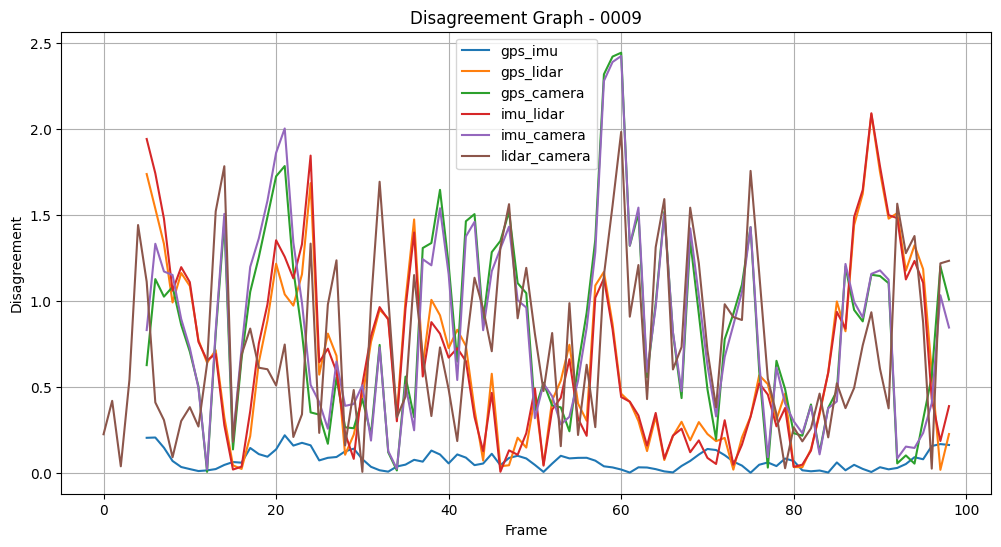

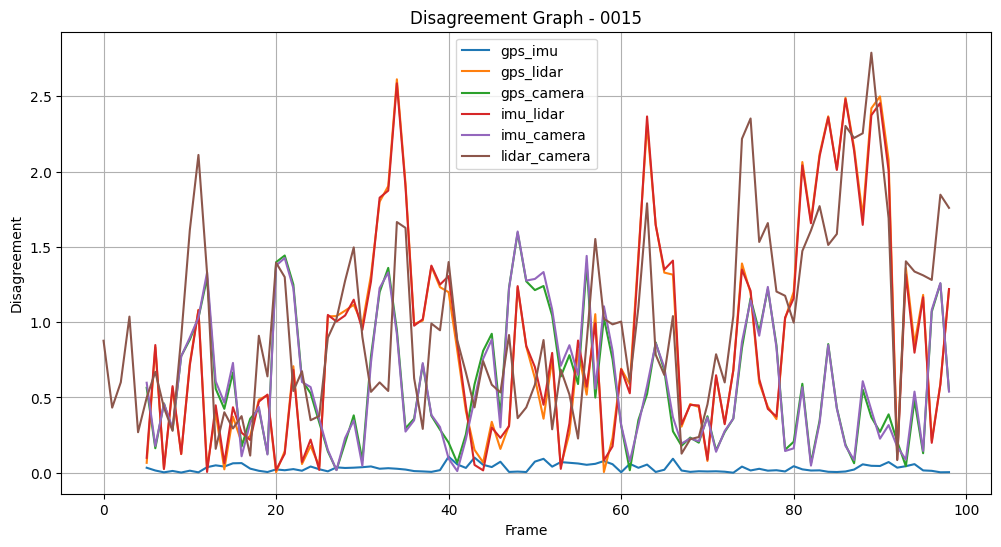

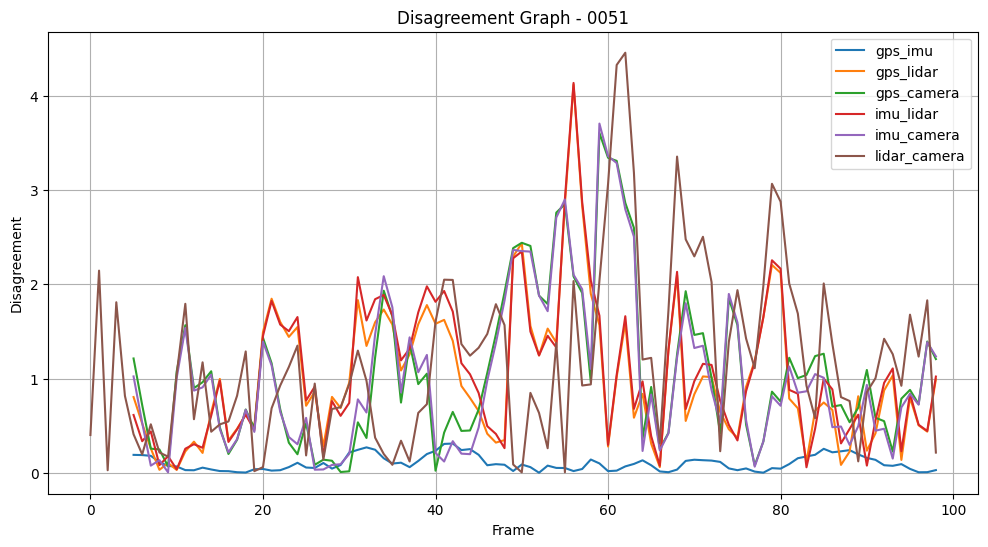

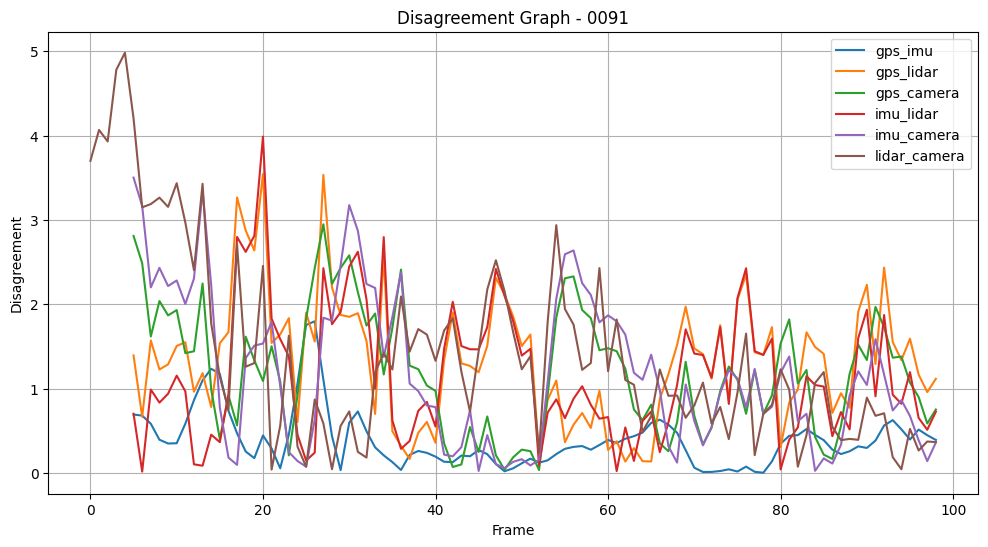

In [7]:
for drive, r in results.items():

    plt.figure(figsize=(12,6))

    for edge, values in r["graph"].items():

        plt.plot(
            values,
            label=edge
        )

    plt.title(
        f"Disagreement Graph - {drive}"
    )

    plt.xlabel("Frame")
    plt.ylabel("Disagreement")

    plt.legend()
    plt.grid(True)

    plt.show()

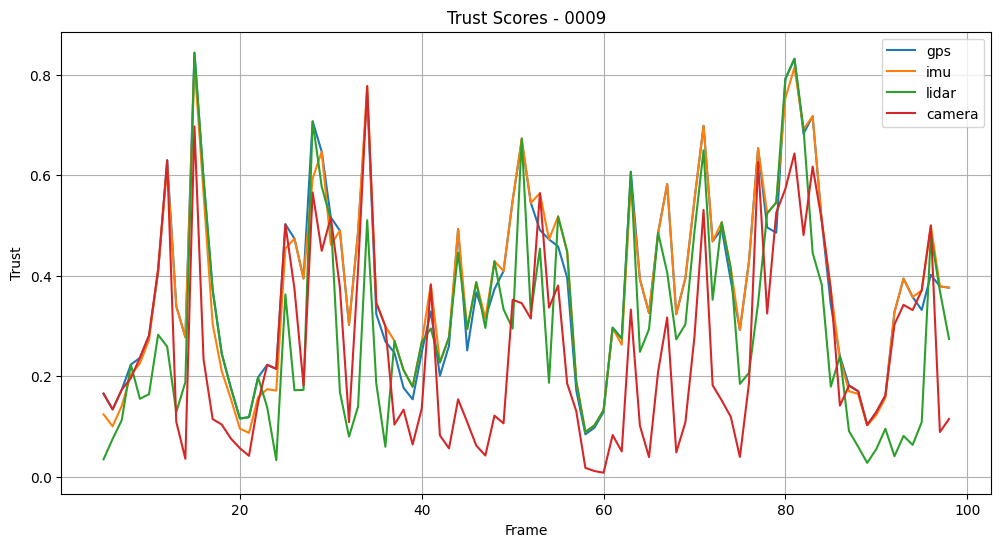

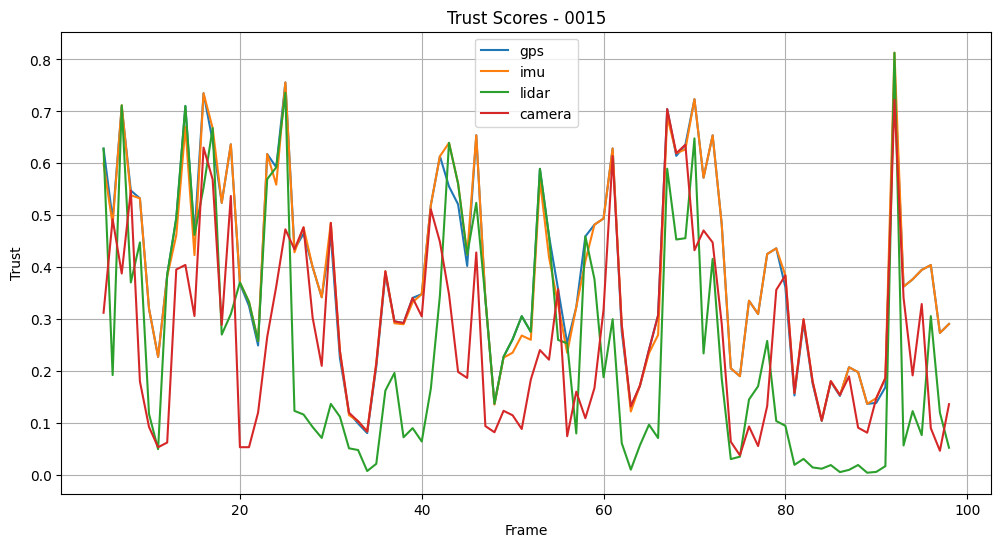

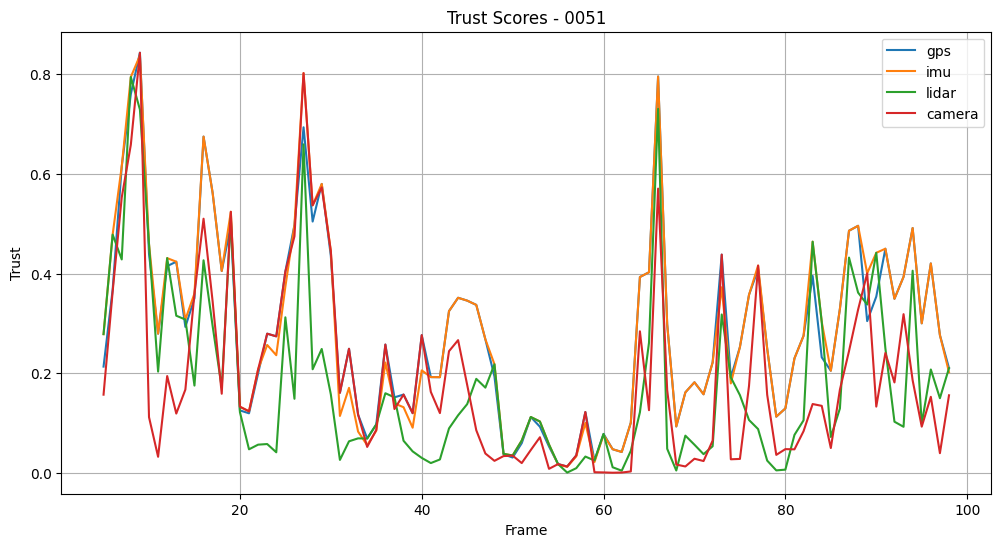

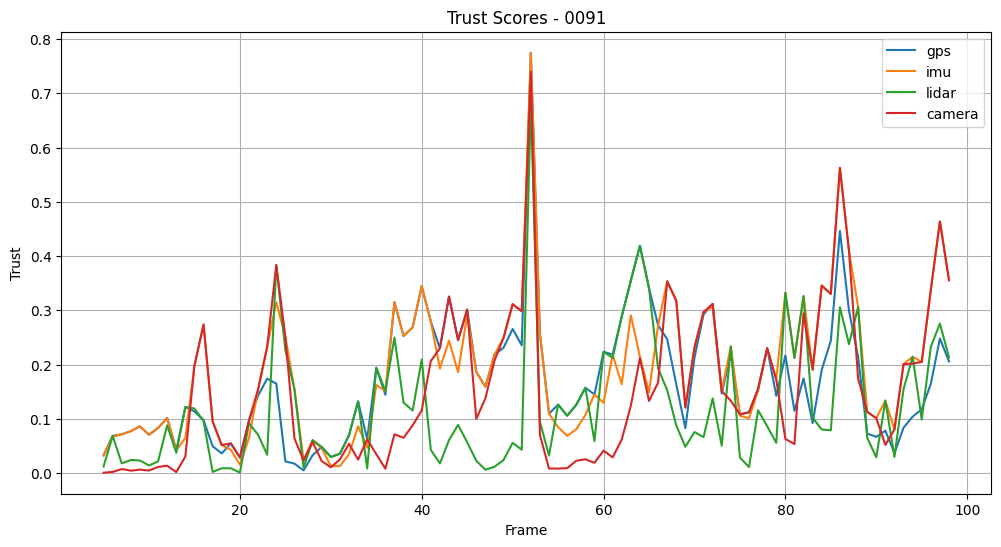

In [8]:
for drive, r in results.items():

    plt.figure(figsize=(12,6))

    for sensor, values in r["trust"].items():

        plt.plot(
            values,
            label=sensor
        )

    plt.title(
        f"Trust Scores - {drive}"
    )

    plt.xlabel("Frame")
    plt.ylabel("Trust")

    plt.legend()
    plt.grid(True)

    plt.show()

In [9]:
print("\n===== TRUST SUMMARY =====")

for drive, r in results.items():

    print(f"\nDrive {drive}")

    for sensor, values in r["trust"].items():

        print(
            f"{sensor:10s}"
            f"mean={np.nanmean(values):.4f}"
        )


===== TRUST SUMMARY =====

Drive 0009
gps       mean=0.3809
imu       mean=0.3814
lidar     mean=0.2995
camera    mean=0.2531

Drive 0015
gps       mean=0.3926
imu       mean=0.3910
lidar     mean=0.2514
camera    mean=0.2712

Drive 0051
gps       mean=0.2875
imu       mean=0.2904
lidar     mean=0.1805
camera    mean=0.1936

Drive 0091
gps       mean=0.1689
imu       mean=0.1919
lidar     mean=0.1223
camera    mean=0.1504


In [10]:
print("\n===== VALIDATION =====")

for drive, r in results.items():

    print(f"\nDrive {drive}")

    valid = True

    for sensor, trust in r["trust"].items():

        if np.nanmin(trust) < 0:
            valid = False

        if np.nanmax(trust) > 1:
            valid = False

    print(
        "Trust range valid:",
        valid
    )


===== VALIDATION =====

Drive 0009
Trust range valid: True

Drive 0015
Trust range valid: True

Drive 0051
Trust range valid: True

Drive 0091
Trust range valid: True
